In [40]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import pearsonr

In [41]:
df = pd.read_csv('train.csv')
df.describe(include='all').transpose()

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
id,630000.0,NaN,NaN,NaN,314999.5,181865.479132,0.0,157499.75,314999.5,472499.25,629999.0
Age,630000.0,NaN,NaN,NaN,54.136706,8.256301,29.0,48.0,54.0,60.0,77.0
Sex,630000.0,NaN,NaN,NaN,0.714735,0.451541,0.0,0.0,1.0,1.0,1.0
Chest pain type,630000.0,NaN,NaN,NaN,3.312752,0.851615,1.0,3.0,4.0,4.0,4.0
BP,630000.0,NaN,NaN,NaN,130.497433,14.975802,94.0,120.0,130.0,140.0,200.0
Cholesterol,630000.0,NaN,NaN,NaN,245.011814,33.681581,126.0,223.0,243.0,269.0,564.0
FBS over 120,630000.0,NaN,NaN,NaN,0.079987,0.271274,0.0,0.0,0.0,0.0,1.0
EKG results,630000.0,NaN,NaN,NaN,0.98166,0.998783,0.0,0.0,0.0,2.0,2.0
Max HR,630000.0,NaN,NaN,NaN,152.816763,19.112927,71.0,142.0,157.0,166.0,202.0
Exercise angina,630000.0,NaN,NaN,NaN,0.273725,0.44587,0.0,0.0,0.0,1.0,1.0


In [42]:
df.head()

,id,Age,Sex,Chest pain type,BP,Cholesterol,FBS over 120,EKG results,Max HR,Exercise angina,ST depression,Slope of ST,Number of vessels fluro,Thallium,Heart Disease
0,0,58,1,4,152,239,0,0,158,1,3.6,2,2,7,Presence
1,1,52,1,1,125,325,0,2,171,0,0.0,1,0,3,Absence
2,2,56,0,2,160,188,0,2,151,0,0.0,1,0,3,Absence
3,3,44,0,3,134,229,0,2,150,0,1.0,2,0,3,Absence
4,4,58,1,4,140,234,0,2,125,1,3.8,2,3,3,Presence


In [43]:
# Map the target variable to more descriptive labels
df["Heart Disease"] = df["Heart Disease"].replace({"Absence": 0, "Presence": 1})
df["Heart Disease"] = df["Heart Disease"].astype('int64')
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 630000 entries, 0 to 629999
Data columns (total 15 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   id                       630000 non-null  int64  
 1   Age                      630000 non-null  int64  
 2   Sex                      630000 non-null  int64  
 3   Chest pain type          630000 non-null  int64  
 4   BP                       630000 non-null  int64  
 5   Cholesterol              630000 non-null  int64  
 6   FBS over 120             630000 non-null  int64  
 7   EKG results              630000 non-null  int64  
 8   Max HR                   630000 non-null  int64  
 9   Exercise angina          630000 non-null  int64  
 10  ST depression            630000 non-null  float64
 11  Slope of ST              630000 non-null  int64  
 12  Number of vessels fluro  630000 non-null  int64  
 13  Thallium                 630000 non-null  int64  
 14  Heart Disease  

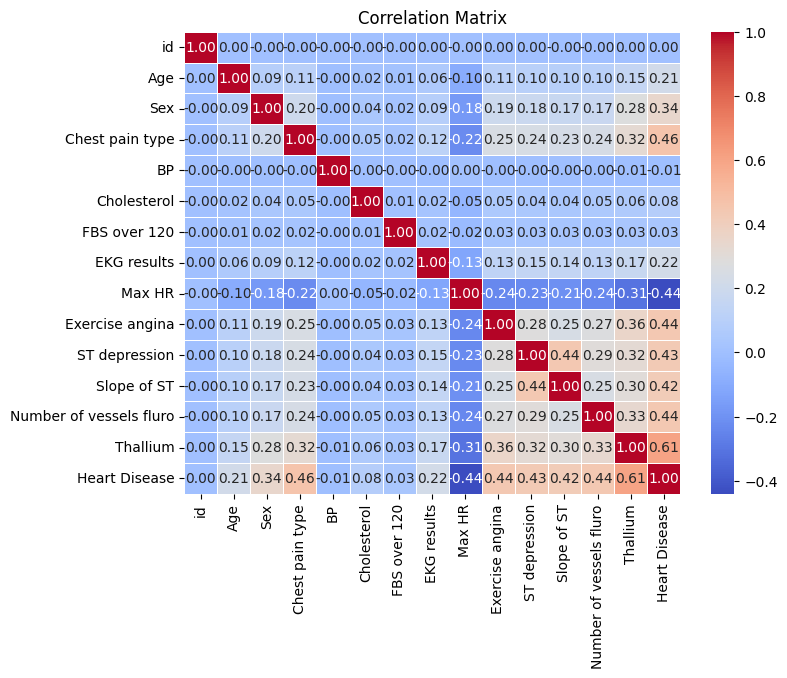

In [44]:
# Correlation matrix
correlation_matrix = df.select_dtypes(include=['number']).corr()

plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)

plt.title('Correlation Matrix')
plt.show()

In [45]:
target_col_name = 'Heart Disease'
feature_target_corr = {}
for col in df:
    if target_col_name != col:
        feature_target_corr[col + '_' + target_col_name] = \
            pearsonr(df[col], df[target_col_name])[0]
print("Feature-Target Correlations")
feature_target_corr


Feature-Target Correlations


{'id_Heart Disease': np.float64(0.0002086949950719511),
 'Age_Heart Disease': np.float64(0.21209131286269042),
 'Sex_Heart Disease': np.float64(0.34244625909208065),
 'Chest pain type_Heart Disease': np.float64(0.4606836013906836),
 'BP_Heart Disease': np.float64(-0.005181026617474512),
 'Cholesterol_Heart Disease': np.float64(0.08275283327169497),
 'FBS over 120_Heart Disease': np.float64(0.03357027699897507),
 'EKG results_Heart Disease': np.float64(0.2189613325027613),
 'Max HR_Heart Disease': np.float64(-0.44098542092817494),
 'Exercise angina_Heart Disease': np.float64(0.441863731450629),
 'ST depression_Heart Disease': np.float64(0.43064059125155646),
 'Slope of ST_Heart Disease': np.float64(0.41505023653259593),
 'Number of vessels fluro_Heart Disease': np.float64(0.4386035431712187),
 'Thallium_Heart Disease': np.float64(0.6057763854486663)}

In [46]:
df.corr()['Heart Disease']

id                         0.000209
Age                        0.212091
Sex                        0.342446
Chest pain type            0.460684
BP                        -0.005181
Cholesterol                0.082753
FBS over 120               0.033570
EKG results                0.218961
Max HR                    -0.440985
Exercise angina            0.441864
ST depression              0.430641
Slope of ST                0.415050
Number of vessels fluro    0.438604
Thallium                   0.605776
Heart Disease              1.000000
Name: Heart Disease, dtype: float64